# Figures 2 and 3

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import networkx as nx
from mastodon_reader import MastodonReader

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np
import colorsys

plt.rcParams.update({'font.size': 18})

In [111]:
import warnings
warnings.filterwarnings('ignore',category=DeprecationWarning)
warnings.filterwarnings('ignore',category=FutureWarning)

In [112]:
def read_graph_mastodon(fname):
    mr = MastodonReader(fname)
    # show meta data
    meta_data = mr.read_metadata()
    # read (networkX) graph representation, spot and link tables with features and tags columns
    graph, spots, links, tag_definition = mr.read(tags=True, features=True)
    return graph,spots #,links,tag_definition

# - remove cycles 
# - keep only one ancestor branches in case of multiple ones


def get_trees_containing_node(graph,tagged_nodes):
    trees = []
    root_nodes = []
    for n in tagged_nodes:
        # generate the subgraph spanned by the the root node
        root_node = [x for x in nx.ancestors(graph,n) if graph.in_degree(x) == 0  ]
        # it may be that the current node is the root one
        if root_node == []:
            root_node = [n]
        assert  len(root_node) == 1
        root_node = root_node[0]
        if root_node in root_nodes:
            # skip already generated trees
            continue
        else:
            root_nodes.append(root_node)
        
        nodes = nx.descendants(graph,root_node) | {root_node}
        if not nodes:
            raise Exception("No root node?!")
        # the subgraph 
        subg = graph.subgraph(nodes).copy()
        # remove all trivial cycles
        # cf: https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.cycles.simple_cycles.html#networkx.algorithms.cycles.simple_cycles
        subg.remove_edges_from(nx.selfloop_edges(subg))
        
        # If we try to get the spanning tree, some edges are missing are missing
        # tree = nx.minimum_spanning_tree(subg.to_undirected())
        # E = set(tree.edges())  # optimization
        # oriented_edges = [e for e in subg.edges() if e in E or reversed(e) in E]
        # subg = graph.subgraph(nodes)
        nodes_to_delete = set()
        for n in subg.nodes():
            predecessors = list(subg.predecessors(n))
            if predecessors:
                # take one of the predecessor, ignore the rest
                nodes_to_keep = nx.ancestors(graph,predecessors[0])
                for pred in predecessors:
                    nodes_to_delete |= nx.ancestors(graph,pred) - nodes_to_keep
        if nodes_to_delete:
            print(f'deleting {len(nodes_to_delete)} nodes')
            subg.remove_nodes_from(nodes_to_delete)
        # do we have a tree ?
        assert nx.is_tree(subg)
        #all_verified_nodes |=  subg.nodes
        trees.append(subg)
    return trees

def get_tagged_trees(graph,tags=['untracked','verified']):
    # the tagged nodes
    tagged_nodes = [ spot for tag in tags for spot in spots[spots[tag+'_NAME'] != ''].index.to_list() ] 
    trees = get_trees_containing_node(graph,tagged_nodes)
    return trees 



In [113]:
def average_over_x(data,binx=1):
    data=np.array(data)
    # averages data[i] = [x[i],y[i]] over x
    ylist=[[] for i in range(0,int(max(data[:,0])/binx)+1)]
    xlist=[[] for i in range(0,int(max(data[:,0])/binx)+1)]
    for d in data:
        i=int(d[0]/binx)
        ylist[i].append(d[1])
        xlist[i].append(d[0])
    x=np.array([np.mean(xl) for xl in xlist if len(xl)>0])
    y=np.array([np.mean(yl) for yl in ylist if len(yl)>0])
    err=np.array([np.std(yl)/np.sqrt(len(yl)) for yl in ylist if len(yl)>0])
    return x,y,err

# Load all necessary data

In [114]:
np.random.seed(1)
colors=[colorsys.hsv_to_rgb(rg[0], 0.5+0.5*rg[1], 1) for rg in np.random.rand(1000,2)]

In [115]:
def get_avg_speed(dat):
    speeds = []
    for pos,time,node_ids in dat:
        #sd = np.sqrt((pos[:,0] - pos[0,0])**2 +(pos[:,1]-pos[0,1])**2)
        dr_vec = np.diff(pos,axis=0)
        dr = np.sqrt(dr_vec[:,0]**2 + dr_vec[:,1]**2)
        speed = dr/np.diff(time)
        avg_speed = np.nanmean(speed,axis=0)
        speeds.append(avg_speed)
    return np.array(speeds) # speeds are in um/h

In [116]:
# manually annotated divisions
dat = {'control':{'file':'1/control/well_B2_center_6_divisions.mastodon', 'label':'control', 'TMZ': 115/6.},
       '500uM':{'file':'1/500um/well_B5_center_5_divisions.mastodon', 'label': r'500$\mathrm{\mu}$M', 'TMZ': 115/6.},
       'control2': {'file': "2/control/well_B2_t106-719_3frames_r35-35-35_center_divisions.mastodon", 'label': 'control', 'TMZ': 106/6.},
       '500uM2': {'file': "2/500um/well_B5_t106-600_5frames_r35-50-50_center_divisions.mastodon", 'label': r'500$\mathrm{\mu}$M', 'TMZ': 106/6.},
       'control3': {'file':"3/control/well_B2_btrack_center_5_divisions.mastodon", 'label':'control', 'TMZ': 121/6.},
       '500uM3': {'file': "3/500um/well_B5_t120-600_bf_labels_3frames_r35-35-35_center_5_divisions.mastodon", 'label': r'500$\mathrm{\mu}$M', 'TMZ': 121/6.}
      } 
for e in dat: 
    dat[e]['graph'],dat[e]['spots'] = read_graph_mastodon("../data/brightfield/150h_replicates/"+dat[e]['file'])
    print(dat[e]['graph'].number_of_nodes())
    #graph,spots,links,tag_definition = #read_graph_mastodon(dat[e]['file'])

/home/idjafc/.miniconda3/envs/pytorch/lib/python3.10/site-packages/mastodon_reader/mastodon_reader.py:463: RuntimeWarning: Warning: Unkown Mastodon feature: Link displacement, skipping
  warnings.warn(
/home/idjafc/.miniconda3/envs/pytorch/lib/python3.10/site-packages/mastodon_reader/mastodon_reader.py:463: RuntimeWarning: Warning: Unkown Mastodon feature: Link velocity, skipping
  warnings.warn(


143390


/home/idjafc/.miniconda3/envs/pytorch/lib/python3.10/site-packages/mastodon_reader/mastodon_reader.py:463: RuntimeWarning: Warning: Unkown Mastodon feature: Link displacement, skipping
  warnings.warn(
/home/idjafc/.miniconda3/envs/pytorch/lib/python3.10/site-packages/mastodon_reader/mastodon_reader.py:463: RuntimeWarning: Warning: Unkown Mastodon feature: Link velocity, skipping
  warnings.warn(


139283


/home/idjafc/.miniconda3/envs/pytorch/lib/python3.10/site-packages/mastodon_reader/mastodon_reader.py:463: RuntimeWarning: Warning: Unkown Mastodon feature: Link displacement, skipping
  warnings.warn(
/home/idjafc/.miniconda3/envs/pytorch/lib/python3.10/site-packages/mastodon_reader/mastodon_reader.py:463: RuntimeWarning: Warning: Unkown Mastodon feature: Link velocity, skipping
  warnings.warn(


...

138580


/home/idjafc/.miniconda3/envs/pytorch/lib/python3.10/site-packages/mastodon_reader/mastodon_reader.py:463: RuntimeWarning: Warning: Unkown Mastodon feature: Link displacement, skipping
  warnings.warn(
/home/idjafc/.miniconda3/envs/pytorch/lib/python3.10/site-packages/mastodon_reader/mastodon_reader.py:463: RuntimeWarning: Warning: Unkown Mastodon feature: Link velocity, skipping
  warnings.warn(


129677


/home/idjafc/.miniconda3/envs/pytorch/lib/python3.10/site-packages/mastodon_reader/mastodon_reader.py:463: RuntimeWarning: Warning: Unkown Mastodon feature: Link displacement, skipping
  warnings.warn(
/home/idjafc/.miniconda3/envs/pytorch/lib/python3.10/site-packages/mastodon_reader/mastodon_reader.py:463: RuntimeWarning: Warning: Unkown Mastodon feature: Link velocity, skipping
  warnings.warn(


143842


In [80]:
col={}
col['control']='green'
col['500uM']='red'
col['control2']='green'
col['500uM2']='red'
col['control3']='green'
col['500uM3']='red'

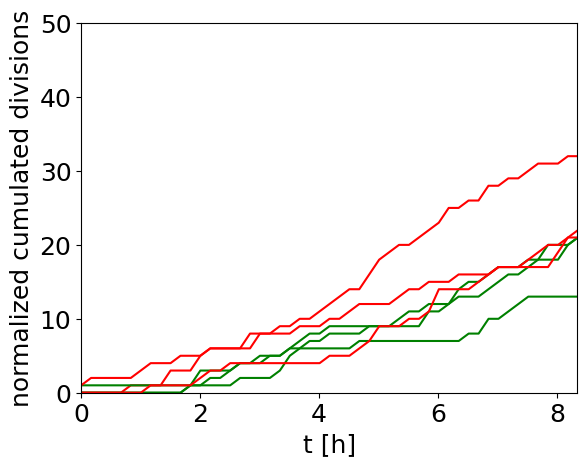

In [110]:
for e in dat:
    spots = dat[e]['spots']
    
    ncells = (spots.groupby('t').apply(len)) #,include_groups=False)) # no. of cells at time t
    
    divs = spots[spots['division_NAME'] == 'true']
    ndivs = np.array(divs.groupby('t').apply(len).reindex(ncells.index).fillna(0))  # this is the number of divions at each time point
    
    #ndivs = divs.groupby('t').apply(len,include_groups=False).reindex(ncells.index).fillna(0)  # Ilyas version
    
    ncells=np.array(ncells)
    
    #print(ndivs)
    ndivs_cum = ndivs.cumsum() # total no of births until time t
    ndivs_norm_cum =(ndivs/ncells[0]).cumsum() # total no of births until time t, divided by the initial no. of cells

    t0=dat[e]['TMZ']
    tt=np.linspace(0,len(ncells)/6.,len(ncells)) #-t0
    #plt.plot(tt,ncells,c=col[e])
    
    
    plt.plot(tt,ndivs_cum,c=col[e])
    plt.xlabel("t [h]")
    plt.ylabel("normalized cumulated divisions")
    plt.xlim(0,50/6)
    plt.ylim(0,50)

# Fig. 2B

(0.0, 106.00657887811865)

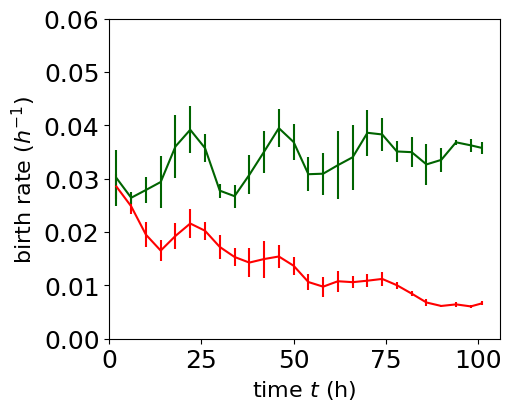

In [142]:
plt.rcParams['text.usetex'] = False
fig,ax = plt.subplots(1,1,figsize=(5,4),layout='constrained')
avgs = {'500uM':[],'control':[]}

def average_over_x(data,binx=1):
    data=np.array(data)
    # averages data[i] = [x[i],y[i]] over x
    ylist=[[] for i in range(0,int(max(data[:,0])/binx)+1)]
    xlist=[[] for i in range(0,int(max(data[:,0])/binx)+1)]
    for d in data:
        i=int(d[0]/binx)
        ylist[i].append(d[1])
        xlist[i].append(d[0])
    x=np.array([np.mean(xl) for xl in xlist if len(xl)>0])
    y=np.array([np.mean(yl) for yl in ylist if len(yl)>0])
    #err=np.array([np.std(yl)/np.sqrt(len(yl)) for yl in ylist if len(yl)>0])
    err=np.array([np.std(yl) for yl in ylist if len(yl)>0])
    return x,y,err

for e in dat:
    dt=1/6.
    spots = dat[e]['spots']
    
    ncells = (spots.groupby('t').apply(len)) # no. of cells at time t
    
    divs = spots[spots['division_NAME'] == 'true']
    ndivs = divs.groupby('t').apply(len).reindex(ncells.index).fillna(0)  # this is the number of divions at each time point
        
    #ncells=np.array(ncells)
    
    #ndivs = ndivs.rolling(50,min_periods=1,closed='both').mean()
    birth_rate=((ndivs/ncells)/dt).rolling(50,min_periods=1,closed='both').mean()
    #birth_rate=np.array((ndivs/ncells)/dt).reshape((-1,20)).mean(axis=1)
    
    t0=dat[e]['TMZ']
    tt=np.linspace(0,len(ncells)*dt,len(ncells))-t0

    birth_rate = np.array(birth_rate)
    ids = tt >= 0
    tt, birth_rate = tt[ids], birth_rate[ids]
    for lab in avgs: 
        if lab in e: 
            avgs[lab].append([tt,np.array(birth_rate)])
    #ax.plot(tt,np.array(birth_rate),c=col[e]) #,label=dat[e]['label'])
    #plt.xlabel("t [h]")
    #plt.ylabel("birth rate [h^-1]")
for lab,c in zip(avgs,['red','darkgreen']):
    x,y,yerr = average_over_x(np.hstack(avgs[lab]).T,binx=4)
    ax.errorbar(x,y,yerr=yerr/np.sqrt(3),color=c)
ax.set_xlabel('time $t$ (h)',fontsize=16)
ax.set_ylabel("birth rate ($h^{-1}$)",fontsize=16)
ax.set_ylim(0,0.06)
ax.set_xlim(0,)
# ax.legend(frameon=False,fontsize=14)
#ax.set_xlim(0,exp_duration)
#plt.savefig(f'plots/birth_rate.svg')

# Fig. 2C

/tmp/ipykernel_1477102/2264188541.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False,fontsize=14)


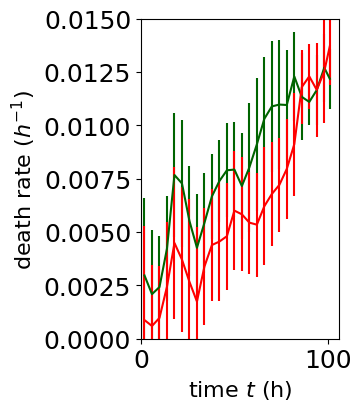

In [141]:
plt.rcParams['text.usetex'] = False
fig,ax = plt.subplots(1,1,figsize=(3.5,4),layout='constrained')
avgs = {'500uM':[],'control':[]}

for e in dat:
    dt=1/6. # time step in [h]
    spots = dat[e]['spots']
    
    ncells = (spots.groupby('t').apply(len)) # no. of cells at time t
    
    divs = spots[spots['division_NAME'] == 'true']
    ndivs = divs.groupby('t').apply(len).reindex(ncells.index).fillna(0)  # this is the number of divions at each time point
    ndivs_cum = ndivs.cumsum() # total no of births until time t
    ndeaths  = ndivs_cum +ncells[0] - ncells  # total no of deaths until time t
    ndeaths = ndeaths.rolling(200,min_periods=1,closed='both').mean().diff()
    death_rate = (ndeaths/ncells)/dt #.ffill()
    
    t0=dat[e]['TMZ']
    tt=np.linspace(0,len(ncells)*dt,len(ncells))-t0
    ids = tt >= 0
    tt, death_rate = tt[ids], death_rate[ids]
    #plt.plot(tt,ncells,c=col[e])
    for lab in avgs: 
        if lab in e: 
            avgs[lab].append([tt,np.array(death_rate)])
    
    #plt.plot(tt,nbirths_normed_cumulated,c=col[e])
    #ax.plot(tt,np.array(death_rate),c=col[e]) #,label=dat[e]['label'])


for lab,c in zip(['control','500uM'],['darkgreen','red']): 
    x,y,yerr = average_over_x(np.hstack(avgs[lab]).T,binx=4)
    ax.errorbar(x,y,yerr=yerr/np.sqrt(3),color=c)
ax.set_xlabel('time $t$ (h)',fontsize=16)
ax.set_ylabel("death rate ($h^{-1}$)",fontsize=16)
ax.set_ylim(0,0.0150)
ax.set_xlim(0,)
ax.legend(frameon=False,fontsize=14)
#ax.set_xlim(0,exp_duration)
#plt.savefig(f'plots/death_rate.svg')

In [27]:
roots=[node for node, degree in graph.in_degree() if degree == 0]
print(len(roots))
plt.hist([graph.nodes[v]['t'] for v in roots])

NameError: name 'graph' is not defined

In [148]:
def get_trajs_starting_at_node(g,v0):
    trajs=[[v0]]
    trajs_out=[]
    while len(trajs)>0:
        traj=trajs.pop()
        while True:
            outlinks=list(g.out_edges(traj[-1]))
        #print(outlinks)
            if len(outlinks)==1:
                traj.append(outlinks[0][1])
            elif len(outlinks)==0:
                trajs_out.append(traj)
                #print(traj)
                break
            else:
                #traj.append(outlinks[0][1])
                trajs_out.append(traj)
                #print(traj)
                for l in outlinks:
                    trajs.append([traj[-1],l[1]])
                break
    return trajs_out
#trajs=get_trajs_starting_at_node(graph,roots[2])
#print(trajs)

In [156]:
[graph.nodes[v]['t'] for v in trajs[3]]

[133.0, 134.0, 135.0, 136.0, 137.0, 138.0, 139.0, 140.0, 141.0, 142.0]

In [160]:
trajs=[]
for v in roots:
    trajs = trajs + get_trajs_starting_at_node(graph,v) 

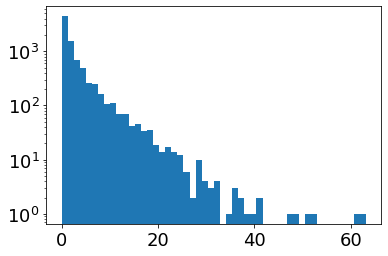

In [166]:
DTs=[(graph.nodes[tr[-1]]['t']-graph.nodes[tr[0]]['t'])/6. for tr in trajs]
plt.hist(DTs,bins=50)
plt.yscale('log')
plt.show()

In [147]:
def get_all_trajs(gragh):
    roots=[node for node, degree in graph.in_degree() if degree == 0]
    trajs=[]
    for v in roots:
        trajs = trajs + get_trajs_starting_at_node(graph,v) 
    return trajs

# Fig. 2D based on centre-well tracks - do not use this figure!

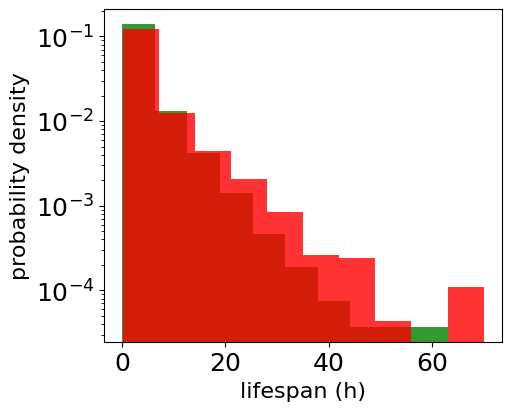

In [32]:
fig,ax = plt.subplots(figsize=(5,4),layout='constrained',squeeze=False)
for e in dat:
    #print(exper)
    graph=dat[e]['graph']
    trajs=get_all_trajs(graph)
    lifespans=[(graph.nodes[tr[-1]]['t']-graph.nodes[tr[0]]['t'])/6. for tr in trajs]
    #div_times,div_types = get_div_times_lintree(dat)
    #div_times  = div_times/60

    #print('{} {} \t mean: {} std: {}'.format(exp_label,lab,div_times.mean(),div_times.std()))
    #for j,lab_div_type,cnd in zip(range(2),['all',],[div_types > -2,div_types == 1]):
    ax[0][0].hist(lifespans,color=col[e],label=dat[e]['label'],density=True,alpha=0.8)

ax[0][0].set_xlabel('lifespan (h)',fontsize=16)
ax[0][0].set_ylabel('probability density',fontsize=16) 
#plt.savefig('../figures/plots/histogram_lifespans_{}.svg'.format(exp_label))
ax[0][0].set_yscale('log')
plt.show()

In [38]:
#set([graph.nodes[v]['division_NAME'] for v in graph.nodes])
len([v for v in graph.nodes if graph.nodes[v]['division_NAME']=='true'])

326

# proportion of cells arrested
no trajectories below extend from t=1 to t=719 so this approach may not work

In [252]:
graph=dat['control']['graph']
trajs=get_all_trajs(graph)

In [256]:
tmax=max([graph.nodes[v]['t'] for v in graph.nodes])
print(tmax)

719.0


In [260]:
max([graph.nodes[traj[-1]]['t']-graph.nodes[traj[0]]['t'] for traj in trajs])

379.0

# Fig 3B

In [143]:
# Mastodon files with automated tracks

#dat2 = {'control':{'file':'../data/brightfield/150h_replicates/1/control/well_B2_5frames_r35_50_50_t116-600.mastodon', 'label':'control'},
#       '500uM':{'file':'../data/brightfield/150h_replicates/1/500um/well_B5_5frames_r35_50_50_t116-600.mastodon', 'label': r'500$\mathrm{\mu}$M'}
#      } 

dat2 = {'control1':{'file':'../data/brightfield/150h_replicates/1/control/well_B2_5frames_r35_50_50_t116-600.mastodon', 'label':'control'},
       '500uM1':{'file':'../data/brightfield/150h_replicates/1/500um/well_B5_5frames_r35_50_50_t116-600.mastodon', 'label': r'500$\mathrm{\mu}$M'},
        'control2':{'file':'../data/brightfield/150h_replicates/2/control/well_B2_t106-600_5frames_r35-50-50.mastodon', 'label':'control'},
       '500uM2':{'file':'../data/brightfield/150h_replicates/2/500um/well_B5_t106-600_5frames_r35-50-50.mastodon', 'label': r'500$\mathrm{\mu}$M'},
        'control3':{'file':'../data/brightfield/150h_replicates/3/control/well_B2_t120-600_bf_labels_3frames_r35-35-35.mastodon', 'label':'control'},
       '500uM3':{'file':'../data/brightfield/150h_replicates/3/500um/well_B5_t120-600_bf_labels_3frames_r35-35-35.mastodon', 'label': r'500$\mathrm{\mu}$M'}
      } 


for e in dat2: 
    dat2[e]['graph'],dat2[e]['spots'] = read_graph_mastodon(dat2[e]['file'])

/home/idjafc/.miniconda3/envs/pytorch/lib/python3.10/site-packages/mastodon_reader/mastodon_reader.py:463: RuntimeWarning: Warning: Unkown Mastodon feature: Link displacement, skipping
  warnings.warn(
/home/idjafc/.miniconda3/envs/pytorch/lib/python3.10/site-packages/mastodon_reader/mastodon_reader.py:463: RuntimeWarning: Warning: Unkown Mastodon feature: Link velocity, skipping
  warnings.warn(
/home/idjafc/.miniconda3/envs/pytorch/lib/python3.10/site-packages/mastodon_reader/mastodon_reader.py:463: RuntimeWarning: Warning: Unkown Mastodon feature: Link displacement, skipping
  warnings.warn(
/home/idjafc/.miniconda3/envs/pytorch/lib/python3.10/site-packages/mastodon_reader/mastodon_reader.py:463: RuntimeWarning: Warning: Unkown Mastodon feature: Link velocity, skipping
  warnings.warn(
/home/idjafc/.miniconda3/envs/pytorch/lib/python3.10/site-packages/mastodon_reader/mastodon_reader.py:463: RuntimeWarning: Warning: Unkown Mastodon feature: Link displacement, skipping
  warnings.warn

In [144]:
dt=1/6.
col={}
col['control1']='green'
col['500uM1']='red'
col['control2']='green'
col['500uM2']='red'
col['control3']='green'
col['500uM3']='red'

In [145]:
def get_avg_speed_2(graph,trajs,step=1):
    speeds = []
    for traj in trajs:
        if len(traj)>10: # only trajectories with more than this many nodes are taken
            xyt=np.array([[graph.nodes[v]['x'],graph.nodes[v]['y'],graph.nodes[v]['t']*dt] for v in traj])
            #dxyt = np.diff(xyt,axis=0)
            dxyt=xyt[step::]-xyt[0:-step:]
            #dxyt=np.diff(xyt[::step],axis=0)
            dr = np.sqrt(dxyt[:,0]**2 + dxyt[:,1]**2)
            speed = dr/dxyt[:,2]
            avg_speed = np.nanmean(speed,axis=0)
            speeds.append(avg_speed)
    return np.array(speeds) # speeds are in um/h

0.5202685336897571
0.5460451588407298
0.5386343966822358
0.5932605715120779
0.5521602256549788
0.5581372036196102


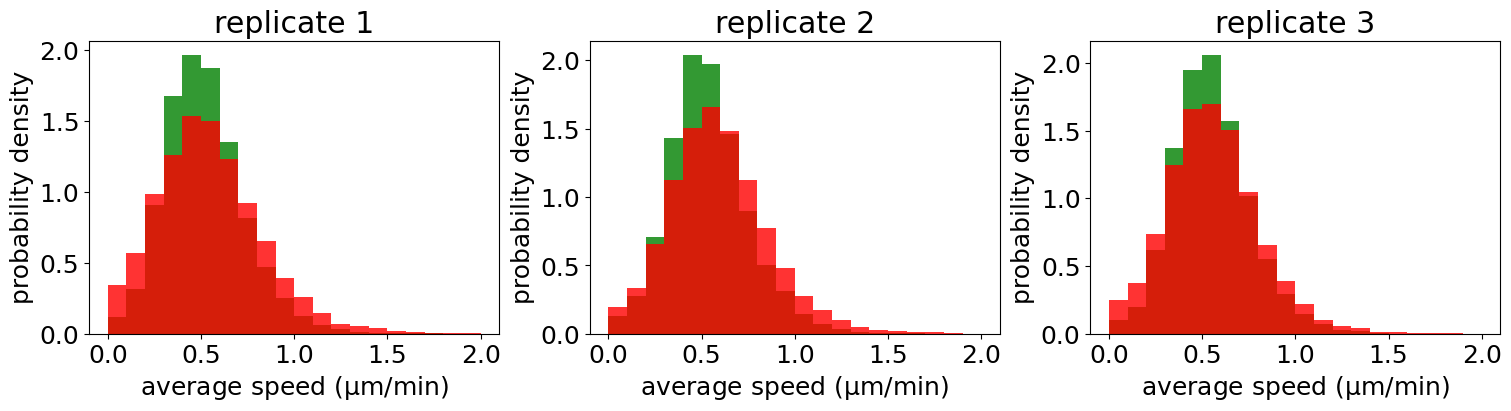

In [36]:
fig,ax = plt.subplots(1,3,figsize=(15,4),layout='constrained',squeeze=False)
j=0
for e in dat2:
    graph=dat2[e]['graph']
    trajs=get_all_trajs(graph)
    speeds=get_avg_speed_2(graph,trajs,3)/60. # convert from um/h to um/min
    print(np.mean(speeds))
    #speeds=np.random.rand(100)
    ax[0][j//2].hist(speeds,bins=20,range=(0,2),color=col[e],label=dat2[e]['label'],density=True,alpha=0.8)

    ax[0][j//2].set_title("replicate "+str(1+j//2))
    ax[0][j//2].set_xlabel('average speed ($\mathrm{\mu}$m/min)')
    ax[0][j//2].set_ylabel('probability density')
    j+=1
#plt.savefig('../figures/plots/histogram_lifespans_{}.svg'.format(exp_label))
plt.savefig('../figures/plots/distributions_avg_speed_3reps_separate.svg')#,bbox_inches='constrained')
plt.show()

0.5202685336897571
0.5460451588407298
0.5386343966822358
0.5932605715120779
0.5521602256549788
0.5581372036196102


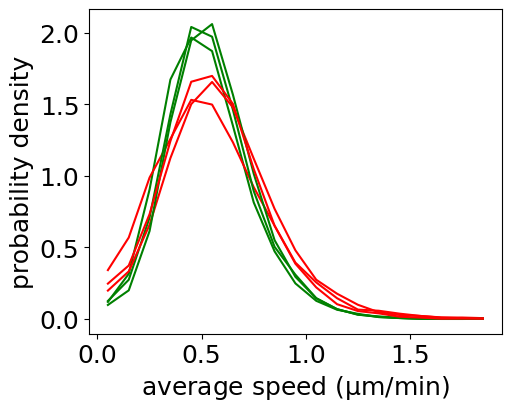

In [37]:
fig,ax = plt.subplots(1,1,figsize=(5,4),layout='constrained',squeeze=False)

for e in dat2:
    graph=dat2[e]['graph']
    trajs=get_all_trajs(graph)
    speeds=get_avg_speed_2(graph,trajs,3)/60. # convert from um/h to um/min
    print(np.mean(speeds))
    #speeds=np.random.rand(100)
    c,b =np.histogram(speeds,bins=np.arange(0,2.0,0.1),density=True)
    ax[0][0].plot((b[1:]+b[:-1])*0.5,c,color=col[e],label=dat2[e]['label'])

    
ax[0][0].set_xlabel('average speed ($\mathrm{\mu}$m/min)')
ax[0][0].set_ylabel('probability density')

#plt.savefig('../figures/plots/histogram_lifespans_{}.svg'.format(exp_label))
plt.savefig('../figures/plots/distributions_avg_speed_3reps_oneplot.svg')#,bbox_inches='constrained')
plt.show()

0.4873544546710189
0.5673736753413489
0.519397997678852
0.5963491716057693
0.5372104908068398
0.5752758037013731


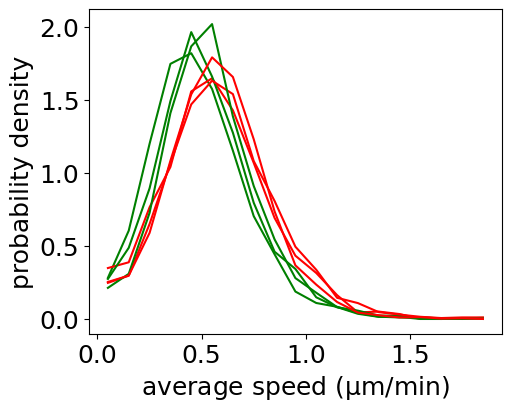

In [39]:
fig,ax = plt.subplots(1,1,figsize=(5,4),layout='constrained',squeeze=False)

for e in dat2:
    graph=dat2[e]['graph']
    trajs=get_all_trajs(graph)
    trajs=[[v for v in traj if (graph.nodes[v]['t']>40*6 and graph.nodes[v]['t']<60*6)] for traj in trajs]
    speeds=get_avg_speed_2(graph,trajs,3)/60. # convert from um/h to um/min
    print(np.mean(speeds))
    #speeds=np.random.rand(100)
    c,b =np.histogram(speeds,bins=np.arange(0,2.0,0.1),density=True)
    ax[0][0].plot((b[1:]+b[:-1])*0.5,c,color=col[e],label=dat2[e]['label'])

    
ax[0][0].set_xlabel('average speed ($\mathrm{\mu}$m/min)')
ax[0][0].set_ylabel('probability density')

#plt.savefig('../figures/plots/histogram_lifespans_{}.svg'.format(exp_label))
plt.savefig('../figures/plots/distributions_avg_speed_3reps_midtime_oneplot.svg')#,bbox_inches='constrained')
plt.show()

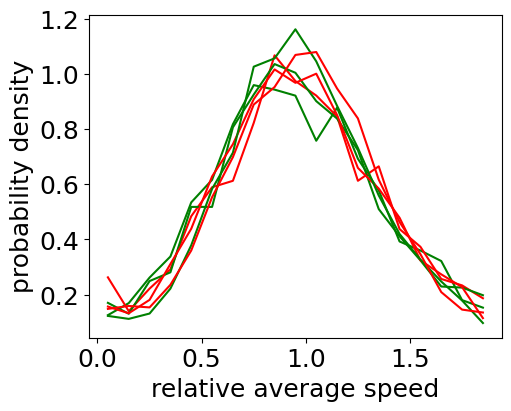

In [40]:
# relative velocity
fig,ax = plt.subplots(1,1,figsize=(5,4),layout='constrained',squeeze=False)

for e in dat2:
    graph=dat2[e]['graph']
    trajs=get_all_trajs(graph)
    trajs=[[v for v in traj if (graph.nodes[v]['t']>40*6 and graph.nodes[v]['t']<60*6)] for traj in trajs]
    speeds=get_avg_speed_2(graph,trajs,3)/60. # convert from um/h to um/min
    speeds=speeds/np.mean(speeds)
    
    #speeds=np.random.rand(100)
    c,b =np.histogram(speeds,bins=np.arange(0,2.0,0.1),density=True)
    ax[0][0].plot((b[1:]+b[:-1])*0.5,c,color=col[e],label=dat2[e]['label'])

    
ax[0][0].set_xlabel('relative average speed')
ax[0][0].set_ylabel('probability density')

#plt.savefig('../figures/plots/histogram_lifespans_{}.svg'.format(exp_label))
plt.savefig('../figures/plots/distributions_relative_avg_speed_3reps_midtime_oneplot.svg')#,bbox_inches='constrained')
plt.show()

In [171]:
def get_speed_2(graph,trajs,step=1):
    speeds = []
    for traj in trajs:
        if len(traj)>10: # only trajectories with more than this many nodes are taken
            xyt=np.array([[graph.nodes[v]['x'],graph.nodes[v]['y'],graph.nodes[v]['t']*dt] for v in traj])
            speed = [[xyt[i,2],(1/60.)*np.sqrt((xyt[i+step,0]-xyt[i,0])**2 + (xyt[i+step,1]-xyt[i,1])**2)/(xyt[i+step,2]-xyt[i,2])] 
                      for i in range(0,len(xyt)-step,step)]
            speeds.append(speed)
    return speeds # speeds are in um/min

def bin_xy_data(data,qx=1,dropnan=False,bincounts=False):
    from numpy.ma import MaskedArray
    # data in the form of a list of pairs of lists [x] and [y] of coordinates
    xx,yy=[[]],[[]]
    for n,d in enumerate(data):
        d=np.array(d)
        x,y=d[:,0],d[:,1]
        for i in range(0,len(x)):
            if dropnan is True:                
                if (np.isnan(x[i]) or np.isnan(y[i])
                    or isinstance(x[i],MaskedArray)
                    or isinstance(y[i],MaskedArray)) :
                    continue
            j=int(x[i]/qx)
            if (j<len(xx)):
                yy[j].append(y[i])
                xx[j].append(x[i])
            else:
                yy.append([])
                xx.append([])
    # if dropnan:
    #     return [np.nanmean(x) for x in xx],[np.nanmean(y) for y in yy], [np.std(y)/np.sqrt(sum(~np.isnan(y))) for y in yy]
    if bincounts:
        return [np.mean(x) for x in xx],[np.mean(y) for y in yy],[np.std(y)/np.sqrt(len(y)) for y in yy],[ len(x) for x in xx]
    return [np.mean(x) for x in xx],[np.mean(y) for y in yy],[np.std(y)/np.sqrt(len(y)) for y in yy]

1.1630418554685324
1.2326525315055294
1.20313828299474
1.290874066972559
1.1379059645493395
1.2320863864412746


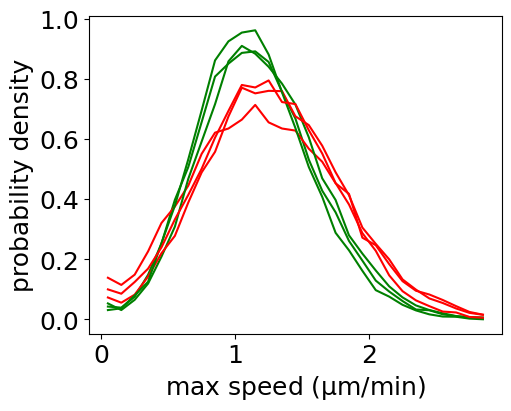

In [44]:
# maximum speed along a trajectory, all times
fig,ax = plt.subplots(1,1,figsize=(5,4),layout='constrained',squeeze=False)

for e in dat2:
    graph=dat2[e]['graph']
    trajs=get_all_trajs(graph)
    #trajs=[[v for v in traj if (graph.nodes[v]['t']>40*6 and graph.nodes[v]['t']<60*6)] for traj in trajs]
    #speeds=get_avg_speed_2(graph,trajs,3)/60. # convert from um/h to um/min
    vels=get_speed_2(graph,trajs,3)
    #print(vels[0])
    speeds=[np.max(np.array(tr)[:,1]) for tr in vels]
    print(np.mean(speeds))
    #speeds=np.random.rand(100)
    c,b =np.histogram(speeds,bins=np.arange(0,3.0,0.1),density=True)
    ax[0][0].plot((b[1:]+b[:-1])*0.5,c,color=col[e],label=dat2[e]['label'])

    
ax[0][0].set_xlabel('max speed ($\mathrm{\mu}$m/min)')
ax[0][0].set_ylabel('probability density')

plt.savefig('../figures/plots/distributions_avg_speed_3reps_midtime_oneplot.svg')#,bbox_inches='constrained')
plt.show()

0.4866072887634538
0.5422638981670762
0.517148813070138
0.5790081002371796
0.5369970625028649
0.5591737259514822


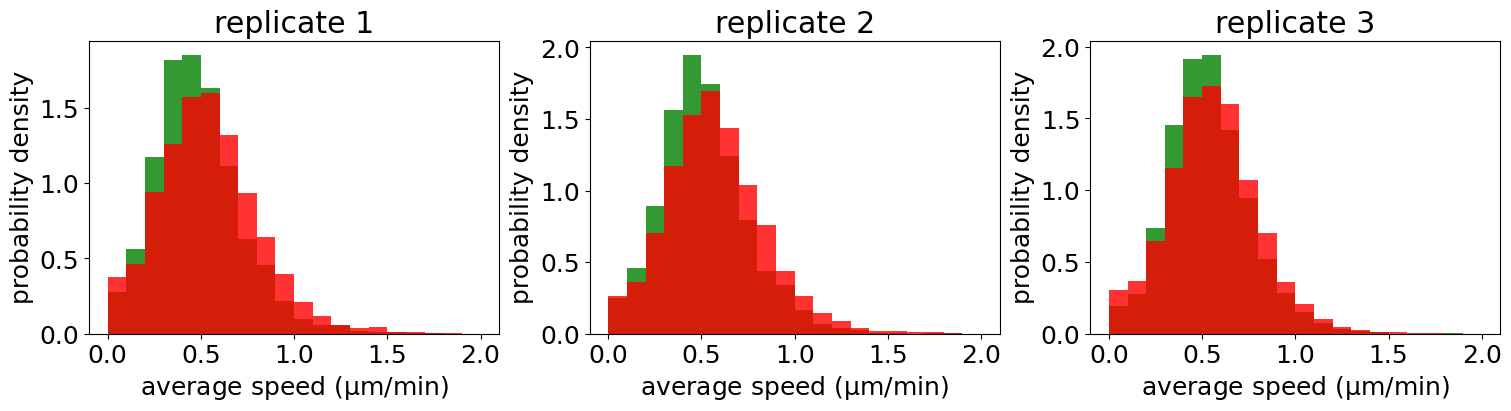

In [46]:
fig,ax = plt.subplots(1,3,figsize=(15,4),layout='constrained',squeeze=False)
j=0
for e in dat2:
    graph=dat2[e]['graph']
    trajs=get_all_trajs(graph)
    trajs=[[v for v in traj if (graph.nodes[v]['t']>100 and graph.nodes[v]['t']<400)] for traj in trajs]
    speeds=get_avg_speed_2(graph,trajs,3)/60. # convert from um/h to um/min
    print(np.mean(speeds))
    #speeds=np.random.rand(100)
    ax[0][j//2].hist(speeds,bins=20,range=(0,2),color=col[e],label=dat2[e]['label'],density=True,alpha=0.8)

    ax[0][j//2].set_title("replicate "+str(1+j//2))
    ax[0][j//2].set_xlabel('average speed ($\mathrm{\mu}$m/min)')
    ax[0][j//2].set_ylabel('probability density')
    j+=1
#plt.savefig('../figures/plots/histogram_lifespans_{}.svg'.format(exp_label))
plt.savefig('../figures/plots/distributions_avg_speed_3reps_midtime_separate.svg')#,bbox_inches='constrained')
plt.show()

# Fig. 3B true

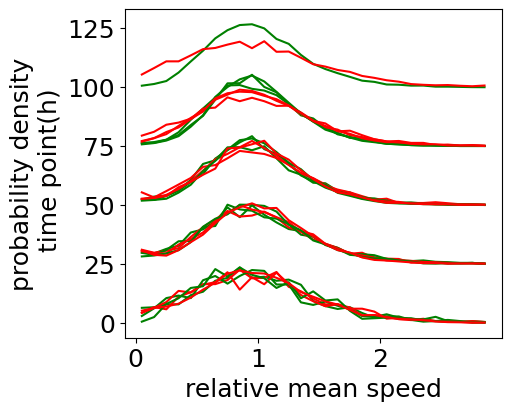

In [158]:
fig,ax = plt.subplots(1,1,figsize=(5,4),layout='constrained')
j=0

bin_t = 25*6
bins = [[] for i in range(5)]
for e in dat2:
    graph=dat2[e]['graph']
    trajs=get_all_trajs(graph)
    for i in range(5):
        bin_trajs=[[v for v in traj if (graph.nodes[v]['t']>= i*bin_t and graph.nodes[v]['t']< (i+1)*bin_t)] for traj in trajs]
        speeds=get_avg_speed_2(graph,bin_trajs,3)/60. # convert from um/h to um/min
        #print(np.mean(speeds))
        #speeds=np.random.rand(100)
        speeds/= np.mean(speeds)
        c,b =np.histogram(speeds,bins=np.arange(0,3.0,0.1),density=True)
        ax.plot((b[1:]+b[:-1])*0.5,bin_t/6*(c+i),color=col[e],label=dat2[e]['label'])
    
#ax.set_title("replicate "+str(1+j//2))
ax.set_xlabel('relative mean speed')
ax.set_ylabel('probability density\n time point(h)')

#plt.savefig('../figures/plots/histogram_lifespans_{}.svg'.format(exp_label))
#plt.savefig('../figures/plots/distributions_avg_speed_3reps_midtime_separate.svg')#,bbox_inches='constrained')
plt.show()

# Fig. 3A

/home/bwaclaw/miniconda3/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/bwaclaw/miniconda3/lib/python3.8/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/home/bwaclaw/miniconda3/lib/python3.8/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/bwaclaw/miniconda3/lib/python3.8/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/home/bwaclaw/miniconda3/lib/python3.8/site-packages/numpy/core/_methods.py:257: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/home/bwaclaw/miniconda3/lib/python3.8/site-packages/numpy/core/_methods.py

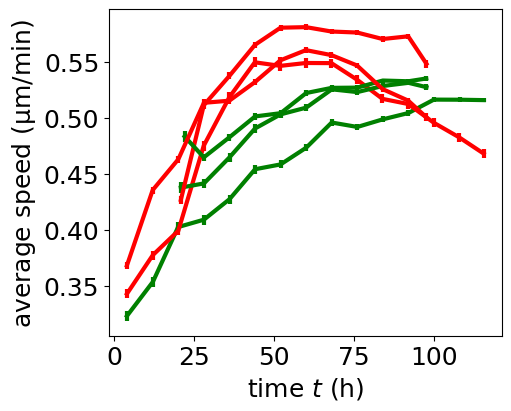

In [47]:
fig,ax = plt.subplots(1,1,figsize=(5,4),layout='constrained',squeeze=False)
for e in dat2:
    graph=dat2[e]['graph']
    trajs=get_all_trajs(graph)
    vels=get_speed_2(graph,trajs,3)
    
    x,y,err = bin_xy_data(vels,qx=8) 

    ax[0][0].errorbar(x,y,err,lw=3,color=col[e],label=dat2[e]['label'])
    #ax[0][0].set_title("replicate "+str(1+j//2))
ax[0][0].set_xlabel('time $t$ (h)')
ax[0][0].set_ylabel('average speed ($\mathrm{\mu}$m/min)')
plt.savefig('../figures/plots/avg_speed_vs_time_3reps.svg')
plt.show()

# mother-daughter speed correlation

starting for n_divs =  15081
PearsonRResult(statistic=0.8832576160911686, pvalue=0.0)


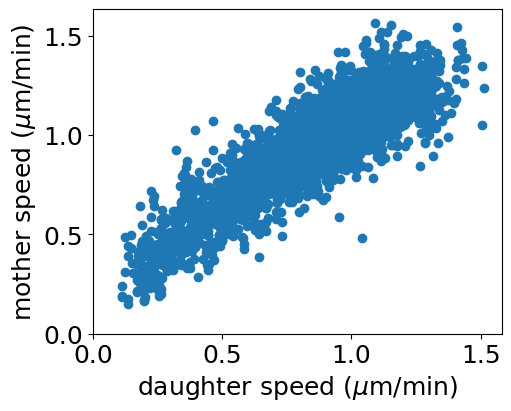

In [53]:
# alternative way
import scipy.stats as stats

#graph=dat['500uM']['graph']
graph=dat2['control1']['graph']

fig, ax = plt.subplots(figsize=(5,4),layout='constrained')   
divs=[v for v in graph.nodes() if (graph.out_degree(v)==2)] # and graph.nodes[v]['division_NAME']=='true')]
step=3
vs1,vs2=[],[]
vvs1,vvs2=[],[]
divs_included=[]
print("starting for n_divs = ",len(divs))
for v0 in divs:
    v=v0
    mother=[]
    while True:
        mother.append(v)
        v=list(graph.predecessors(v))
        #if (len(v)>1):
        #    xxx
        if len(v)==0:
            break
        if graph.out_degree(v[0])>1:
            mother.append(v[0])
            break
        else:
            v=v[0]
    mother=np.flip(mother)
    
    for v in list(graph.successors(v0)):
        daughter=[]
        while True:
            daughter.append(v)
            v=list(graph.successors(v))
            if len(v)==0:
                break
            if graph.out_degree(v[0])>1:
                daughter.append(v[0])
                break
            else:
                v=v[0]
        #print(daughter)
    
        if (len(mother)>20 and len(daughter)>20):
            divs_included.append(v0)
            #print(mother,daughter)
            #mother=mother[-10:]
            #daughter=daughter[:10]
            xyt=np.array([[graph.nodes[v]['x'],graph.nodes[v]['y'],graph.nodes[v]['t']*dt] for v in mother])
            v1 = np.mean([[xyt[i,2],np.sqrt((xyt[i+step,0]-xyt[i,0])**2 + (xyt[i+step,1]-xyt[i,1])**2)/(xyt[i+step,2]-xyt[i,2])] for i in range(0,len(xyt)-step,step)])
            xyt=np.array([[graph.nodes[v]['x'],graph.nodes[v]['y'],graph.nodes[v]['t']*dt] for v in daughter])
            v2 = np.mean([[xyt[i,2],np.sqrt((xyt[i+step,0]-xyt[i,0])**2 + (xyt[i+step,1]-xyt[i,1])**2)/(xyt[i+step,2]-xyt[i,2])] for i in range(0,len(xyt)-step,step)])
            if (np.isfinite(v1) and np.isfinite(v2)):
                #meanv=np.mean(v1+v2)
                #v1=v1/meanv
                #v2=v2/meanv
                vvs1.append(v1/60) # um/min
                vvs2.append(v2/60) # um/min

                        
ax.scatter(vvs1,vvs2)
print(stats.pearsonr(vvs1,vvs2))
ax.set_ylim(0,)
ax.set_xlim(0,)
ax.set_ylabel("mother speed ($\mu$m/min)")
ax.set_xlabel("daughter speed ($\mu$m/min)")
#plt.savefig(currdir+'\\mother_daugther_speed.png',dpi=300)
plt.show()            

# volume vs time

In [168]:
import numpy.linalg as LA
def get_ellipse_axes(x): 
    v = LA.eigvals(np.array([[x['c_11'],x['c_12'],0],
                             [x['c_12'],x['c_22'],0],
                             [0,0,x['c_33']],
                            ])
                  )
    return np.sqrt(np.sort(v))[1:]

# this works on the spots list
def get_area(x):
    a,b=get_ellipse_axes(x)
    return 3.141*a*b

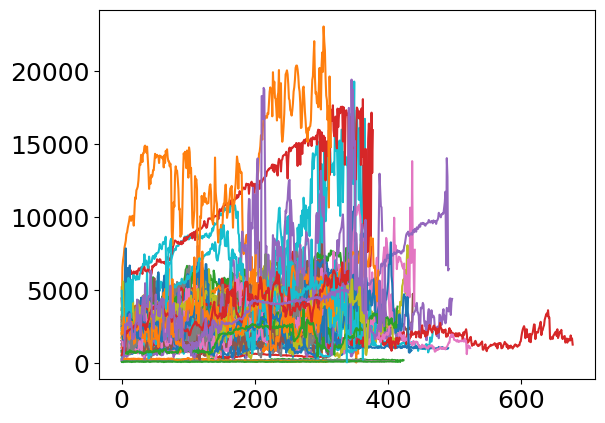

In [27]:
graph=dat2['control1']['graph']
trajs=get_all_trajs(graph)

for tr in trajs:
    if (len(tr)>300):
        vols=[get_area(graph.nodes[v]) for v in tr]
        plt.plot(vols)
plt.show()

# 3C

In [161]:
dat3={'control1':{'file':'../data/brightfield/150h_replicates/1/control/well_B2_5frames_r35_50_50_t116-600.mastodon_bt_graph.gz', 'label':'control'},
       '500uM1':{'file':'../data/brightfield/150h_replicates/1/500um/well_B5_5frames_r35_50_50_t116-600.mastodon_bt_graph.gz', 'label': r'500$\mathrm{\mu}$M'},
        'control2':{'file':'../data/brightfield/150h_replicates/2/control/well_B2_t106-600_5frames_r35-50-50.mastodon_bt_graph.gz', 'label':'control'},
       '500uM2':{'file':'../data/brightfield/150h_replicates/2/500um/well_B5_t106-600_5frames_r35-50-50.mastodon_bt_graph.gz', 'label': r'500$\mathrm{\mu}$M'},
        'control3':{'file':'../data/brightfield/150h_replicates/3/control/well_B2_t120-600_bf_labels_3frames_r35-35-35.mastodon_bt_graph.gz', 'label':'control'},
       '500uM3':{'file':'../data/brightfield/150h_replicates/3/500um/well_B5_t120-600_bf_labels_3frames_r35-35-35.mastodon_bt_graph.gz', 'label': r'500$\mathrm{\mu}$M'}
      }
for e in dat3: 
    dat3[e]['graph'] = nx.read_graphml(dat3[e]['file'])
    print(dat3[e]['graph'].number_of_nodes())
    print(dat3[e]['graph'].number_of_edges())

370419
369192
326580
325560
442094
440454
675087
672404
731751
726626
717881
715901


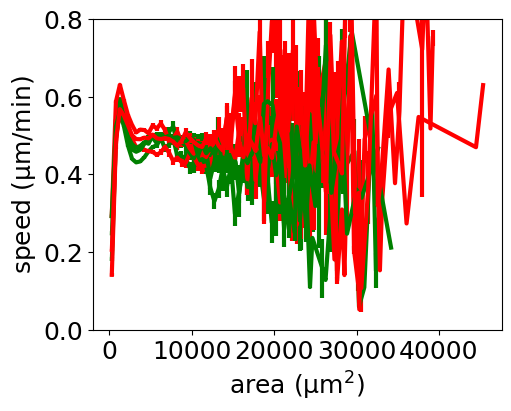

In [51]:
# OLD
def average_over_x(data,binx=1):
    data=np.array(data)
    # averages data[i] = [x[i],y[i]] over x
    ylist=[[] for i in range(0,int(max(data[:,0])/binx)+1)]
    xlist=[[] for i in range(0,int(max(data[:,0])/binx)+1)]
    for d in data:
        i=int(d[0]/binx)
        ylist[i].append(d[1])
        xlist[i].append(d[0])
    x=np.array([np.mean(xl) for xl in xlist if len(xl)>0])
    y=np.array([np.mean(yl) for yl in ylist if len(yl)>0])
    err=np.array([np.std(yl)/np.sqrt(1.*len(yl)) for yl in ylist if len(yl)>0])
    return x,y,err

fig,ax = plt.subplots(figsize=(5,4),layout='constrained',squeeze=False)
for e in dat2:
    graph=dat2[e]['graph']
    trajs=get_all_trajs(graph)

    area_vs_speed=[]
    for tr in trajs:
        if (len(tr)>20):
            #tr=[v for v in tr if (dt*graph.nodes[v]['t']>40 and dt*graph.nodes[v]['t']<80)]
            if (len(tr)!=0):
                
                area=np.array([[dt*graph.nodes[v]['t'],get_area(graph.nodes[v])] for v in tr])
        #print(area[:,0])
                speed=np.array(get_speed_2(graph,[tr],3)[0])
        #print(speed[:,0])
                area_vs_speed.append([[area[np.argmin(np.abs(area[:,0]-t)),1],s] for t,s in speed])
        #print([s for s in speed if int(s[0]) in area[:,0]])
    area_vs_speed=np.concatenate(area_vs_speed)
    #ax[0][0].scatter(area_vs_speed[:,0],area_vs_speed[:,1],s=1,c=col[e])
    
    x,y,err = average_over_x(area_vs_speed,binx=500)

    ax[0][0].errorbar(x,y,err,lw=3,color=col[e],label=dat2[e]['label'])
    ax[0][0].set_ylim(0,0.8)
    
ax[0][0].set_xlabel('area ($\mathrm{\mu}$m$^2$)')
ax[0][0].set_ylabel('speed ($\mathrm{\mu}$m/min)')
plt.savefig('../figures/plots/speed_vs_area_3reps.svg')
plt.show()

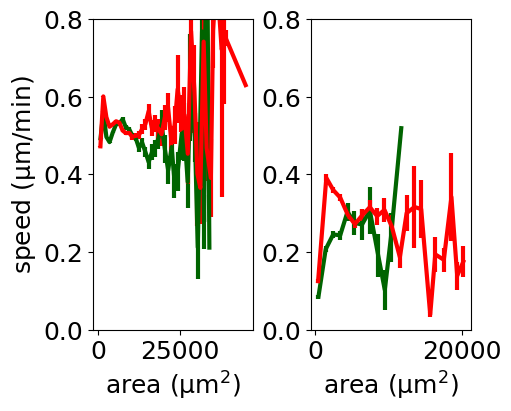

In [189]:
#NEW 
def average_over_x(data,binx=1):
    data=np.array(data)
    # averages data[i] = [x[i],y[i]] over x
    ylist=[[] for i in range(0,int(max(data[:,0])/binx)+1)]
    xlist=[[] for i in range(0,int(max(data[:,0])/binx)+1)]
    for d in data:
        i=int(d[0]/binx)
        ylist[i].append(d[1])
        xlist[i].append(d[0])
    x=np.array([np.mean(xl) for xl in xlist if len(xl)>0])
    y=np.array([np.mean(yl) for yl in ylist if len(yl)>0])
    err=np.array([np.std(yl)/np.sqrt(1.*len(yl)) for yl in ylist if len(yl)>0])
    return x,y,err

fig,ax = plt.subplots(1,2,figsize=(5,4),layout='constrained',squeeze=False)
area_vs_speeds=[[[],[]],
                [[],[]]
               ]
for i,cnd in enumerate(['control','500uM']):
    for e in dat2:
        if cnd in e:
            graph=dat2[e]['graph']
            trajs=get_all_trajs(graph)
            for tr in trajs:
                if (len(tr) <= 10 or ( 200 <=len(tr) <= 400)):
                    continue
                area=np.array([[dt*graph.nodes[v]['t'],get_area(graph.nodes[v])] for v in tr])
                speed=np.array(get_speed_2(graph,[tr],3)[0])
                j = bool(len(tr)//400)
                area_vs_speeds[i][j].append([[area[np.argmin(np.abs(area[:,0]-t)),1],s] for t,s in speed])
                #print([s for s in speed if int(s[0]) in area[:,0]])
for i,cnd in enumerate(['control','500uM']):
    for j,area_vs_speed in enumerate(area_vs_speeds[i]):
        area_vs_speed=np.concatenate(area_vs_speed)
        x,y,err = average_over_x(area_vs_speed,binx=1000)
        ax[0][j].errorbar(x,y,err,lw=3,color='darkgreen' if cnd == 'control' else 'red',label=dat2[e]['label'])
        ax[0][j].set_ylim(0,0.8)
        ax[0][j].set_xlabel('area ($\mathrm{\mu}$m$^2$)')
ax[0][0].set_ylabel('speed ($\mathrm{\mu}$m/min)')
#plt.savefig('../figures/plots/speed_vs_area_3reps.svg')
plt.show()